# Defects Data EDA
This notebook performs exploratory data analysis on the manufacturing defects dataset, covering structure, data quality, category distributions, repair cost behavior, and time trends.

In [23]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

pd.set_option('display.max_columns', None)
sns.set_theme(style='whitegrid')

In [24]:
df = pd.read_csv('defects_data.csv', parse_dates=['defect_date'])
df.head()

,defect_id,product_id,defect_type,defect_date,defect_location,severity,inspection_method,repair_cost
0,1,15,Structural,2024-06-06,Component,Minor,Visual Inspection,245.47
1,2,6,Functional,2024-04-26,Component,Minor,Visual Inspection,26.87
2,3,84,Structural,2024-02-15,Internal,Minor,Automated Testing,835.81
3,4,10,Functional,2024-03-28,Internal,Critical,Automated Testing,444.47
4,5,14,Cosmetic,2024-04-26,Component,Minor,Manual Testing,823.64


In [25]:
print(f'Rows: {df.shape[0]}')
print(f'Columns: {df.shape[1]}')
print(f'Date range: {df["defect_date"].min().date()} to {df["defect_date"].max().date()}')
print('\nDtypes:')
print(df.dtypes)
print('\nMissing values:')
print(df.isna().sum())
print('\nDuplicate rows:', df.duplicated().sum())
print('Duplicate defect IDs:', df['defect_id'].duplicated().sum())

Rows: 1000
Columns: 8
Date range: 2024-01-01 to 2024-06-30

Dtypes:
defect_id                     int64
product_id                    int64
defect_type                  object
defect_date          datetime64[ns]
defect_location              object
severity                     object
inspection_method            object
repair_cost                 float64
dtype: object

Missing values:
defect_id            0
product_id           0
defect_type          0
defect_date          0
defect_location      0
severity             0
inspection_method    0
repair_cost          0
dtype: int64

Duplicate rows: 0
Duplicate defect IDs: 0


In [26]:
summary = df[['product_id', 'repair_cost']].describe().T
summary

,count,mean,std,min,25%,50%,75%,max
product_id,1000.0,50.83700,29.480935,1.00,26.0000,51.00,77.000,100.00
repair_cost,1000.0,507.62715,289.623615,10.22,270.9025,506.43,759.065,999.64


In [27]:
categorical_columns = ['defect_type', 'defect_location', 'severity', 'inspection_method']
for column in categorical_columns:
    print(f'\n{column}')
    print(df[column].value_counts())


defect_type
defect_type
Structural    352
Functional    339
Cosmetic      309
Name: count, dtype: int64

defect_location
defect_location
Surface      353
Component    326
Internal     321
Name: count, dtype: int64

severity
severity
Minor       358
Critical    333
Moderate    309
Name: count, dtype: int64

inspection_method
inspection_method
Manual Testing       352
Visual Inspection    351
Automated Testing    297
Name: count, dtype: int64


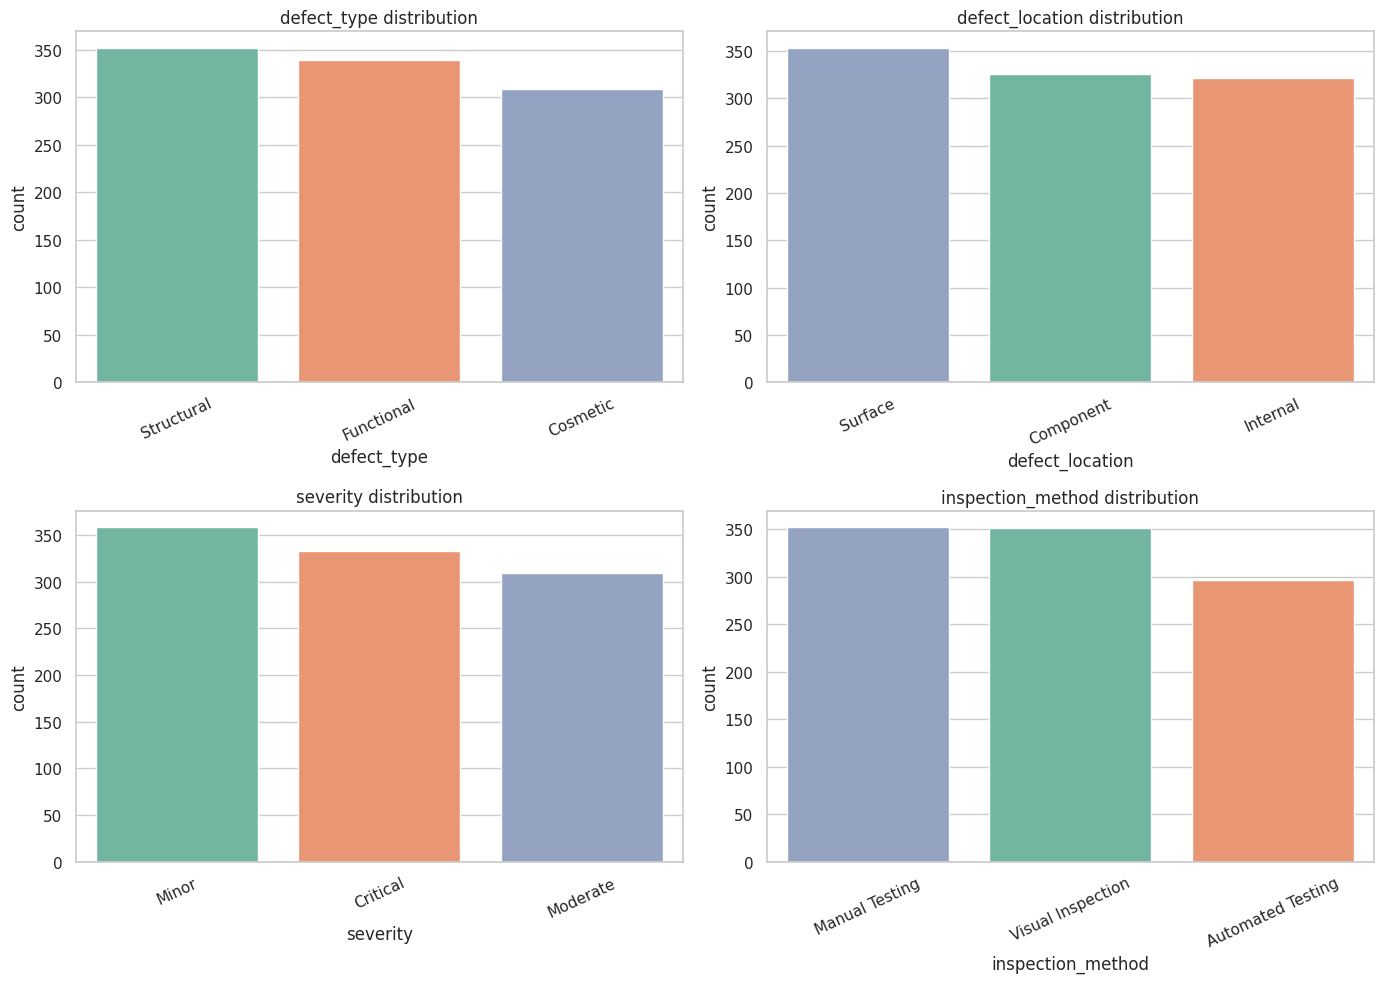

In [28]:
fig, axes = plt.subplots(2, 2, figsize=(14, 10))
for ax, column in zip(axes.flatten(), ['defect_type', 'defect_location', 'severity', 'inspection_method']):
    order = df[column].value_counts().index
    sns.countplot(data=df, x=column, hue=column, order=order, ax=ax, palette='Set2', legend=False)
    ax.set_title(f'{column} distribution')
    ax.tick_params(axis='x', rotation=25)
plt.tight_layout()

,count,mean,median,min,max
severity,,,,,
Critical,333,505.87,503.25,10.22,999.25
Minor,358,514.43,508.37,10.44,998.27
Moderate,309,501.63,498.71,10.55,999.64


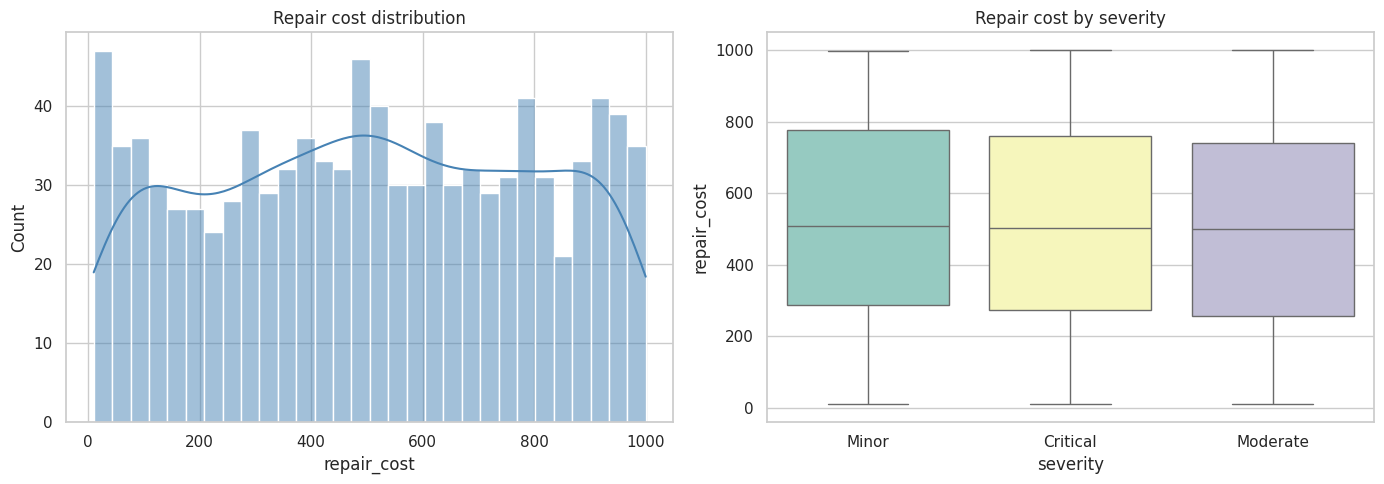

In [29]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
sns.histplot(df['repair_cost'], bins=30, kde=True, ax=axes[0], color='steelblue')
axes[0].set_title('Repair cost distribution')
sns.boxplot(data=df, x='severity', y='repair_cost', hue='severity', ax=axes[1], palette='Set3', legend=False)
axes[1].set_title('Repair cost by severity')
plt.tight_layout()

df.groupby('severity')['repair_cost'].agg(['count', 'mean', 'median', 'min', 'max']).round(2)

In [30]:
cost_views = {
    'avg_cost_by_type': df.groupby('defect_type')['repair_cost'].mean().sort_values(ascending=False).round(2),
    'avg_cost_by_location': df.groupby('defect_location')['repair_cost'].mean().sort_values(ascending=False).round(2),
    'avg_cost_by_method': df.groupby('inspection_method')['repair_cost'].mean().sort_values(ascending=False).round(2),
}
for name, series in cost_views.items():
    print(f'\n{name}')
    print(series)


avg_cost_by_type
defect_type
Cosmetic      513.91
Functional    507.10
Structural    502.62
Name: repair_cost, dtype: float64

avg_cost_by_location
defect_location
Component    532.81
Internal     504.45
Surface      487.26
Name: repair_cost, dtype: float64

avg_cost_by_method
inspection_method
Manual Testing       526.07
Automated Testing    501.80
Visual Inspection    494.05
Name: repair_cost, dtype: float64


defect_date
2024-01    191
2024-02    160
2024-03    175
2024-04    156
2024-05    167
2024-06    151
dtype: int64

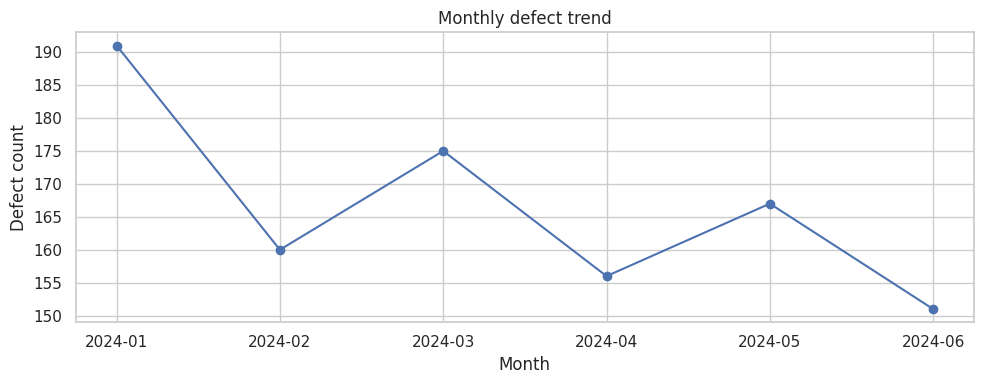

In [31]:
monthly_counts = df.set_index('defect_date').resample('ME').size()
monthly_counts.index = monthly_counts.index.strftime('%Y-%m')
monthly_counts.plot(kind='line', marker='o', figsize=(10, 4), title='Monthly defect trend')
plt.ylabel('Defect count')
plt.xlabel('Month')
plt.tight_layout()
monthly_counts

severity,Critical,Minor,Moderate
defect_type,,,
Cosmetic,107,106,96
Functional,114,113,112
Structural,112,139,101


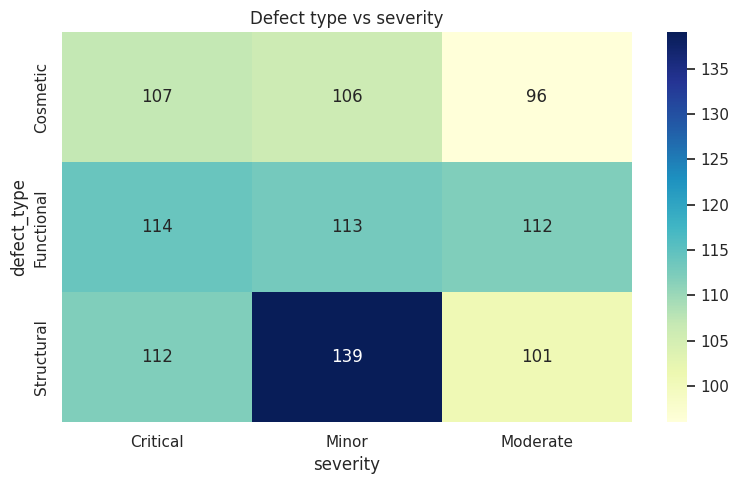

In [32]:
type_severity = pd.crosstab(df['defect_type'], df['severity'])
plt.figure(figsize=(8, 5))
sns.heatmap(type_severity, annot=True, fmt='d', cmap='YlGnBu')
plt.title('Defect type vs severity')
plt.tight_layout()
type_severity

product_id
81    20
63    20
97    19
56    18
10    16
4     16
92    16
74    15
6     15
45    15
Name: count, dtype: int64

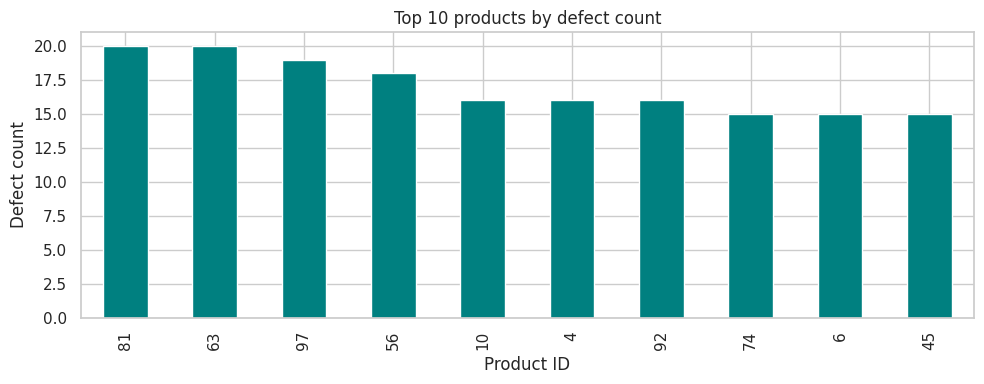

In [33]:
top_products = df['product_id'].value_counts().head(10)
top_products.plot(kind='bar', figsize=(10, 4), color='teal', title='Top 10 products by defect count')
plt.xlabel('Product ID')
plt.ylabel('Defect count')
plt.tight_layout()
top_products

## Key Findings
- The dataset contains 1,000 defect records across 8 columns, covering 2024-01-01 through 2024-06-30.
- No missing values, duplicate rows, or duplicate defect IDs were found, so the dataset is clean enough for direct analysis.
- Defect classes are fairly balanced: Structural (352), Functional (339), and Cosmetic (309). Severity is similarly balanced, with Critical defects making up 33.3% of all records.
- Repair costs range from 10.22 to 999.64, with an average of 507.63 and total recorded cost of 507,627.15.
- Component-level defects have the highest average repair cost (532.81), while Manual Testing is associated with the highest average repair cost among inspection methods (526.07).
- Defect volume trends downward over time in this sample, from 191 records in January to 151 in June.
- Products 81 and 63 have the highest defect counts in the dataset, with 20 records each.